In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

df = pd.read_csv('/content/customer_loan_missing_values.csv')
df.head()

,CustomerID,Age,MonthlyIncome,ExperienceYears,City,Occupation,CreditScore,LoanApproved
0,1,41.0,NaN,16,Mumbai,Engineer,824.0,1
1,2,NaN,138677.0,1,Mumbai,Teacher,596.0,0
2,3,NaN,41216.0,32,Hyderabad,Analyst,575.0,0
3,4,30.0,166737.0,8,Hyderabad,Doctor,836.0,1
4,5,44.0,50540.0,18,Mumbai,Manager,580.0,0


In [3]:
df.info()

print("/nMissing Values")
print(df.isnull().sum())

missing_percentage = (df.isnull().sum()/len(df)*100).round(2)
print("/nMissing Percentage")
print(missing_percentage)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       200 non-null    int64  
 1   Age              182 non-null    float64
 2   MonthlyIncome    173 non-null    float64
 3   ExperienceYears  200 non-null    int64  
 4   City             187 non-null    object 
 5   Occupation       200 non-null    object 
 6   CreditScore      174 non-null    float64
 7   LoanApproved     200 non-null    int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 12.6+ KB
/nMissing Values
CustomerID          0
Age                18
MonthlyIncome      27
ExperienceYears     0
City               13
Occupation          0
CreditScore        26
LoanApproved        0
dtype: int64
/nMissing Percentage
CustomerID          0.0
Age                 9.0
MonthlyIncome      13.5
ExperienceYears     0.0
City                6.5
Occupation          0.0
Cr

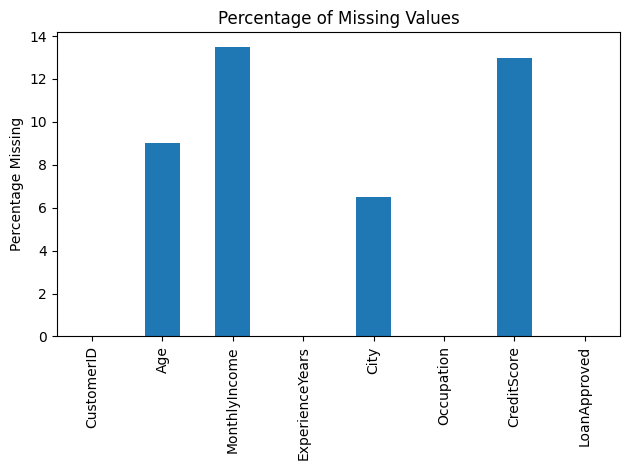

In [4]:
missing_percentage.plot(kind="bar")
plt.title("Percentage of Missing Values")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()

MCAR,MAR, MNAR

In [6]:
numeric=["Age", "MonthlyIncome", "CreditScore"]

median_imp = SimpleImputer(strategy="median")
df[numeric] = median_imp.fit_transform(df[numeric])

cat=["City"]
mode_imp = SimpleImputer(strategy="most_frequent")
df[cat] = mode_imp.fit_transform(df[cat])

print(df.isnull().sum())

CustomerID         0
Age                0
MonthlyIncome      0
ExperienceYears    0
City               0
Occupation         0
CreditScore        0
LoanApproved       0
dtype: int64


In [8]:
df2 = pd.read_csv('/content/customer_loan_missing_values.csv')
df2["IncomeMissing"] = df2["MonthlyIncome"].isnull().astype(int)
print(df2[["MonthlyIncome", "IncomeMissing"]].head(10))



   MonthlyIncome  IncomeMissing
0            NaN              1
1       138677.0              0
2        41216.0              0
3       166737.0              0
4        50540.0              0
5       178501.0              0
6            NaN              1
7       135545.0              0
8       177016.0              0
9       176505.0              0
